# Фінальний звіт: прогнозування відтоку клієнтів

**Neoversity ML Foundations — фінальний проєкт**  
Дата фіналізації: **2 серпня 2026 року**

Цей notebook є формальним академічним звітом. Він не навчає моделі, не завантажує AutoGluon predictor і відтворює таблиці та графіки лише з компактного відстежуваного evidence bundle у `reports/final/`.

In [1]:
# Locate the repository without embedding a machine-specific path.
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = next(
    path
    for path in (Path.cwd(), Path.cwd().parent)
    if (path / 'reports' / 'final' / 'final_results.json').is_file()
)
EVIDENCE_DIR = ROOT / 'reports' / 'final'
evidence = json.loads((EVIDENCE_DIR / 'final_results.json').read_text(encoding='utf-8'))
artifact_manifest = json.loads((EVIDENCE_DIR / 'artifact_manifest.json').read_text(encoding='utf-8'))
print(f"Evidence schema: {evidence['schema_version']}")
print(f"Evidence source commit: {evidence['source_git_commit']}")
print(f"Local immutable-artifact verification recorded as: {artifact_manifest['verification_mode']}")

Evidence schema: final_project_evidence_v1
Evidence source commit: 86f90424ab775e8e5567bbe063e6164dcd21d6dd
Local immutable-artifact verification recorded as: local_immutable_artifacts


## 1. Постановка задачі та метрика

Завдання — бінарна класифікація відтоку клієнтів телеком-компанії. Цільова змінна `y=1` означає позитивний клас. Основна метрика — **Balanced Accuracy**, тобто середнє між sensitivity і specificity. Вона обрана через дисбаланс класів: позитивний клас становить лише 13,05%.

Навчальна вибірка містить 10 000 рядків, тестова — 2 500, а сирий простір — 230 ознак. У train є 1 305 позитивних і 8 695 негативних прикладів. Тому звичайна accuracy могла б приховувати слабке розпізнавання відтоку.

In [2]:
competition = pd.Series(evidence['competition'], name='Значення').to_frame()
display(competition)
datasets = pd.DataFrame(evidence['datasets'])
display(datasets[['dataset_id', 'parent_dataset_id', 'feature_count', 'target_dependency', 'summary']])

,Значення
task,binary telecom churn classification
metric,Balanced Accuracy
train_rows,10000
test_rows,2500
raw_input_features,230
positive_class_count,1305
positive_class_rate,0.1305


,dataset_id,parent_dataset_id,feature_count,target_dependency,summary
0,v0_raw_minimal,None,205,none,Minimal raw baseline after removing constant a...
1,v1_missingness_summary,v0_raw_minimal,213,none,Row-level missingness summaries.
2,v2_missingness_indicators,v0_raw_minimal,393,none,Broad feature-level missingness indicators.
3,v3_targeted_missingness,v1_missingness_summary,217,exploratory,Four target-informed missingness indicators; e...
4,v4_zero_value_summary,v0_raw_minimal,209,none,Row-level zero-value summaries.
5,v5_joint_missingness_pattern,v1_missingness_summary,214,none,Joint missingness-pattern state.
6,v6_compact_missingness_indicators,v1_missingness_summary,247,none,Structurally unique missingness indicators.
7,v7_compact_zero_indicators,v4_zero_value_summary,234,none,Compact feature-level zero indicators.


## 2. Аудит даних, EDA та інженерія ознак

Початковий аудит зафіксував сильний дисбаланс класів, значну кількість пропусків, константні та повністю порожні ознаки, змішані числові й категоріальні типи та потребу зберігати порядок рядків для submission. EDA показав, що missingness і нульові значення можуть описувати стан клієнта або процес збору даних, а не бути лише технічним дефектом.

Ці спостереження були перетворені на вісім immutable Dataset Packages `v0`–`v7`. Кожен пакет фіксує схему, порядок ознак, хеші вмісту, target і row identity, lineage та гіпотезу. `v3_targeted_missingness` є **exploratory і target-informed**: чотири індикатори були вибрані після аналізу зв'язку з target. Тому `v3` не змішується з неупередженим рейтингом пакетів і позначається exploratory в усіх результатах, що від нього залежать.

Політика leakage вимагає виконувати будь-яке target-informed перетворення лише всередині training-частини fold. Test labels, Orange labels та Kaggle Public Score не використовувалися для вибору ознак, threshold або blend weights.

## 3. Моделі та експериментальна платформа

У проєкті оцінювалися Logistic Regression як прозорий baseline, а також CatBoost, LightGBM і XGBoost. Окремий AutoGluon-контур дав bagged-моделі, WeightedEnsemble та neural candidates, але його залежності ізольовані у `.venv-autogluon`.

Платформа була створена, щоб не перетворювати серію notebook на неконтрольований пошук. Dataset Registry зберігає immutable пакети; Research v2 фіксує folds, seeds, threshold protocol, OOF predictions і provenance; порівняння перевіряють row alignment; Blend Campaign Runner виконує відновлювані кампанії з frozen plan; Control Panel є безпечним інтерфейсом до allowlisted команд; генератор submission перевіряє схему, порядок рядків, кількість позитивів і SHA-256.

## 4. Методологія оцінювання

OOF probability для кожного train-рядка формується моделлю, яка не бачила цей рядок під час fit. У repeated/nested validation зовнішні fold оцінюють узагальнення, а threshold обирається лише на meta-training частині. Для blend campaign спочатку фіксується набір probability candidates, потім weights, і лише після цього threshold.

**Honest held-out metric** агрегує рішення, для яких weights і threshold визначалися без відповідного outer holdout. **Descriptive full-OOF metric** застосовує фінальні deployment-параметри до всього OOF-вектора і є корисним описом, але не неупередженою оцінкою. Історичний explicit-OOF протокол, 2-repeat meta-CV native blend і фінальна 5×5 кампанія мають різні protocol labels та не ранжуються як повністю взаємозамінні вимірювання.

In [3]:
confirmation = pd.DataFrame(evidence['campaigns']['confirmation']['results'])
confirmation_view = confirmation[[
    'experiment_id', 'honest_mean_balanced_accuracy',
    'honest_balanced_accuracy_std', 'min_repeat_balanced_accuracy',
    'descriptive_full_oof_balanced_accuracy', 'threshold',
    'test_positive_count'
]].copy()
display(confirmation_view.style.format({
    'honest_mean_balanced_accuracy': '{:.6f}',
    'honest_balanced_accuracy_std': '{:.6f}',
    'min_repeat_balanced_accuracy': '{:.6f}',
    'descriptive_full_oof_balanced_accuracy': '{:.6f}',
    'threshold': '{:.3f}',
}))

,experiment_id,honest_mean_balanced_accuracy,honest_balanced_accuracy_std,min_repeat_balanced_accuracy,descriptive_full_oof_balanced_accuracy,threshold,test_positive_count
0,baseline_a,0.892843,0.001462,0.890291,0.895158,0.117,541
1,confirm_a_b,0.896420,0.000438,0.895712,0.900249,0.125,567
2,confirm_a_d,0.896129,0.001352,0.894466,0.900558,0.117,551
3,confirm_a_h,0.894780,0.001555,0.892477,0.897593,0.226,531


## 5. AutoGluon та фінальна confirmation campaign

Історичний candidate `pc1_d833780dcc6565cb` — `LightGBMPrep_r31_BAG_L1` на exploratory `v3_targeted_missingness`. Його labels точно відтворено з model-specific explicit OOF/test exports без завантаження predictor і без повторного навчання. Він має internal validation Balanced Accuracy 0,895158 за історичним протоколом, threshold 0,117, 541 позитивний прогноз і найкращий перевірений Kaggle Public Score **0,9112**.

Фінальна `exploratory_confirmation_v1` за frozen plan hash `857e146…` використала 5 folds × 5 repeats, seed 42, deterministic native pair optimization і fold-local threshold decisions. A+B отримав найвищий honest mean BA 0,896420 і найменший std 0,000438; A+D — 0,896129; обидва перевищили anchor 0,892843 за тим самим project-owned протоколом. A+H не дав такого підтвердження. Усі blends з A залишаються exploratory через залежність від `v3`.

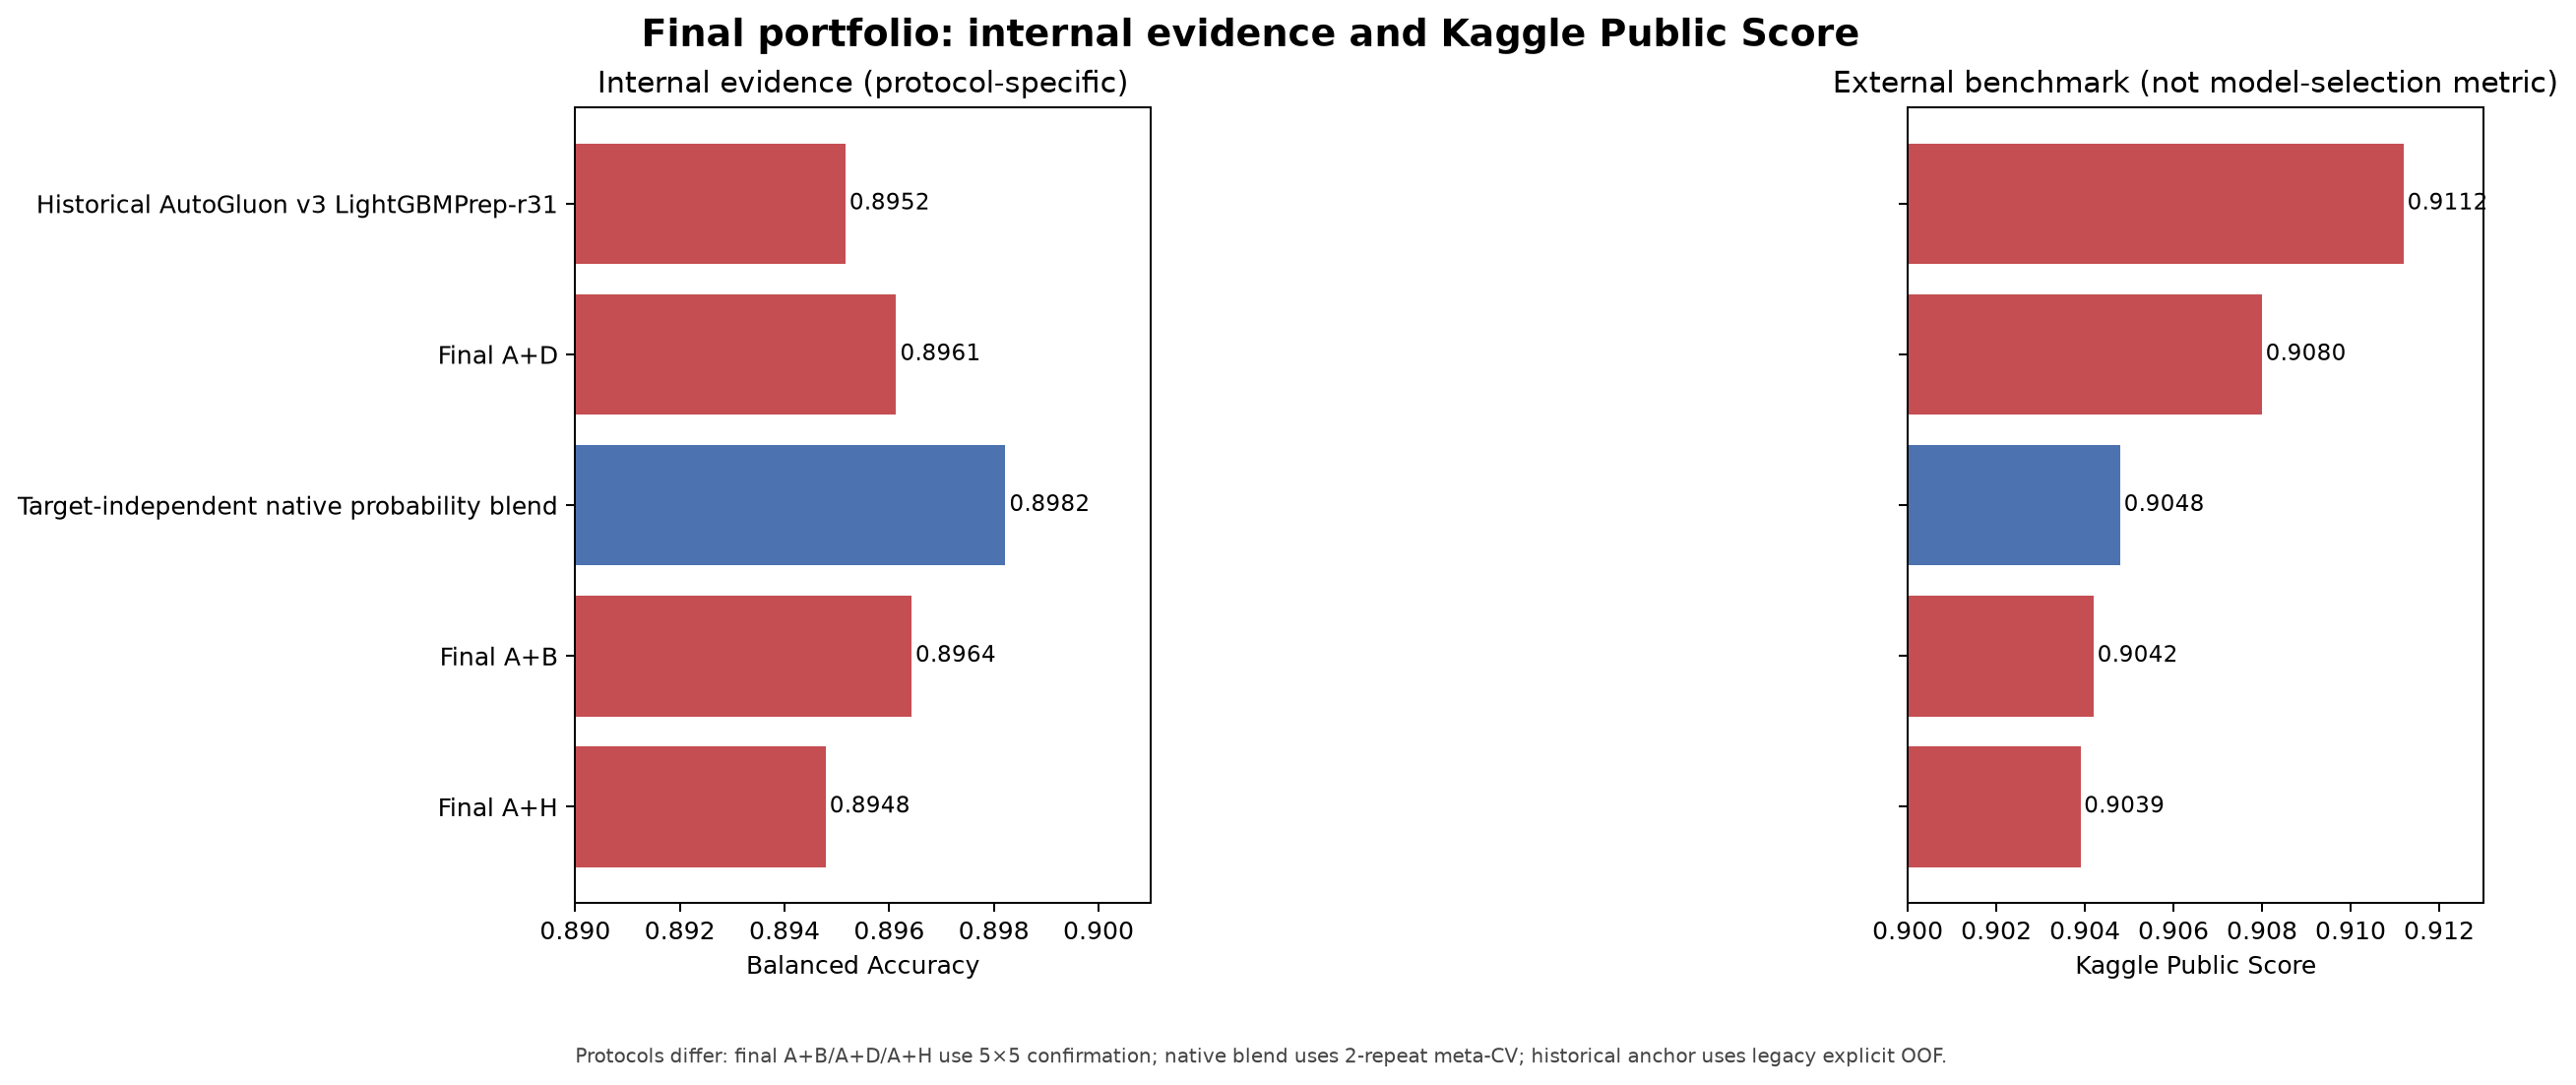

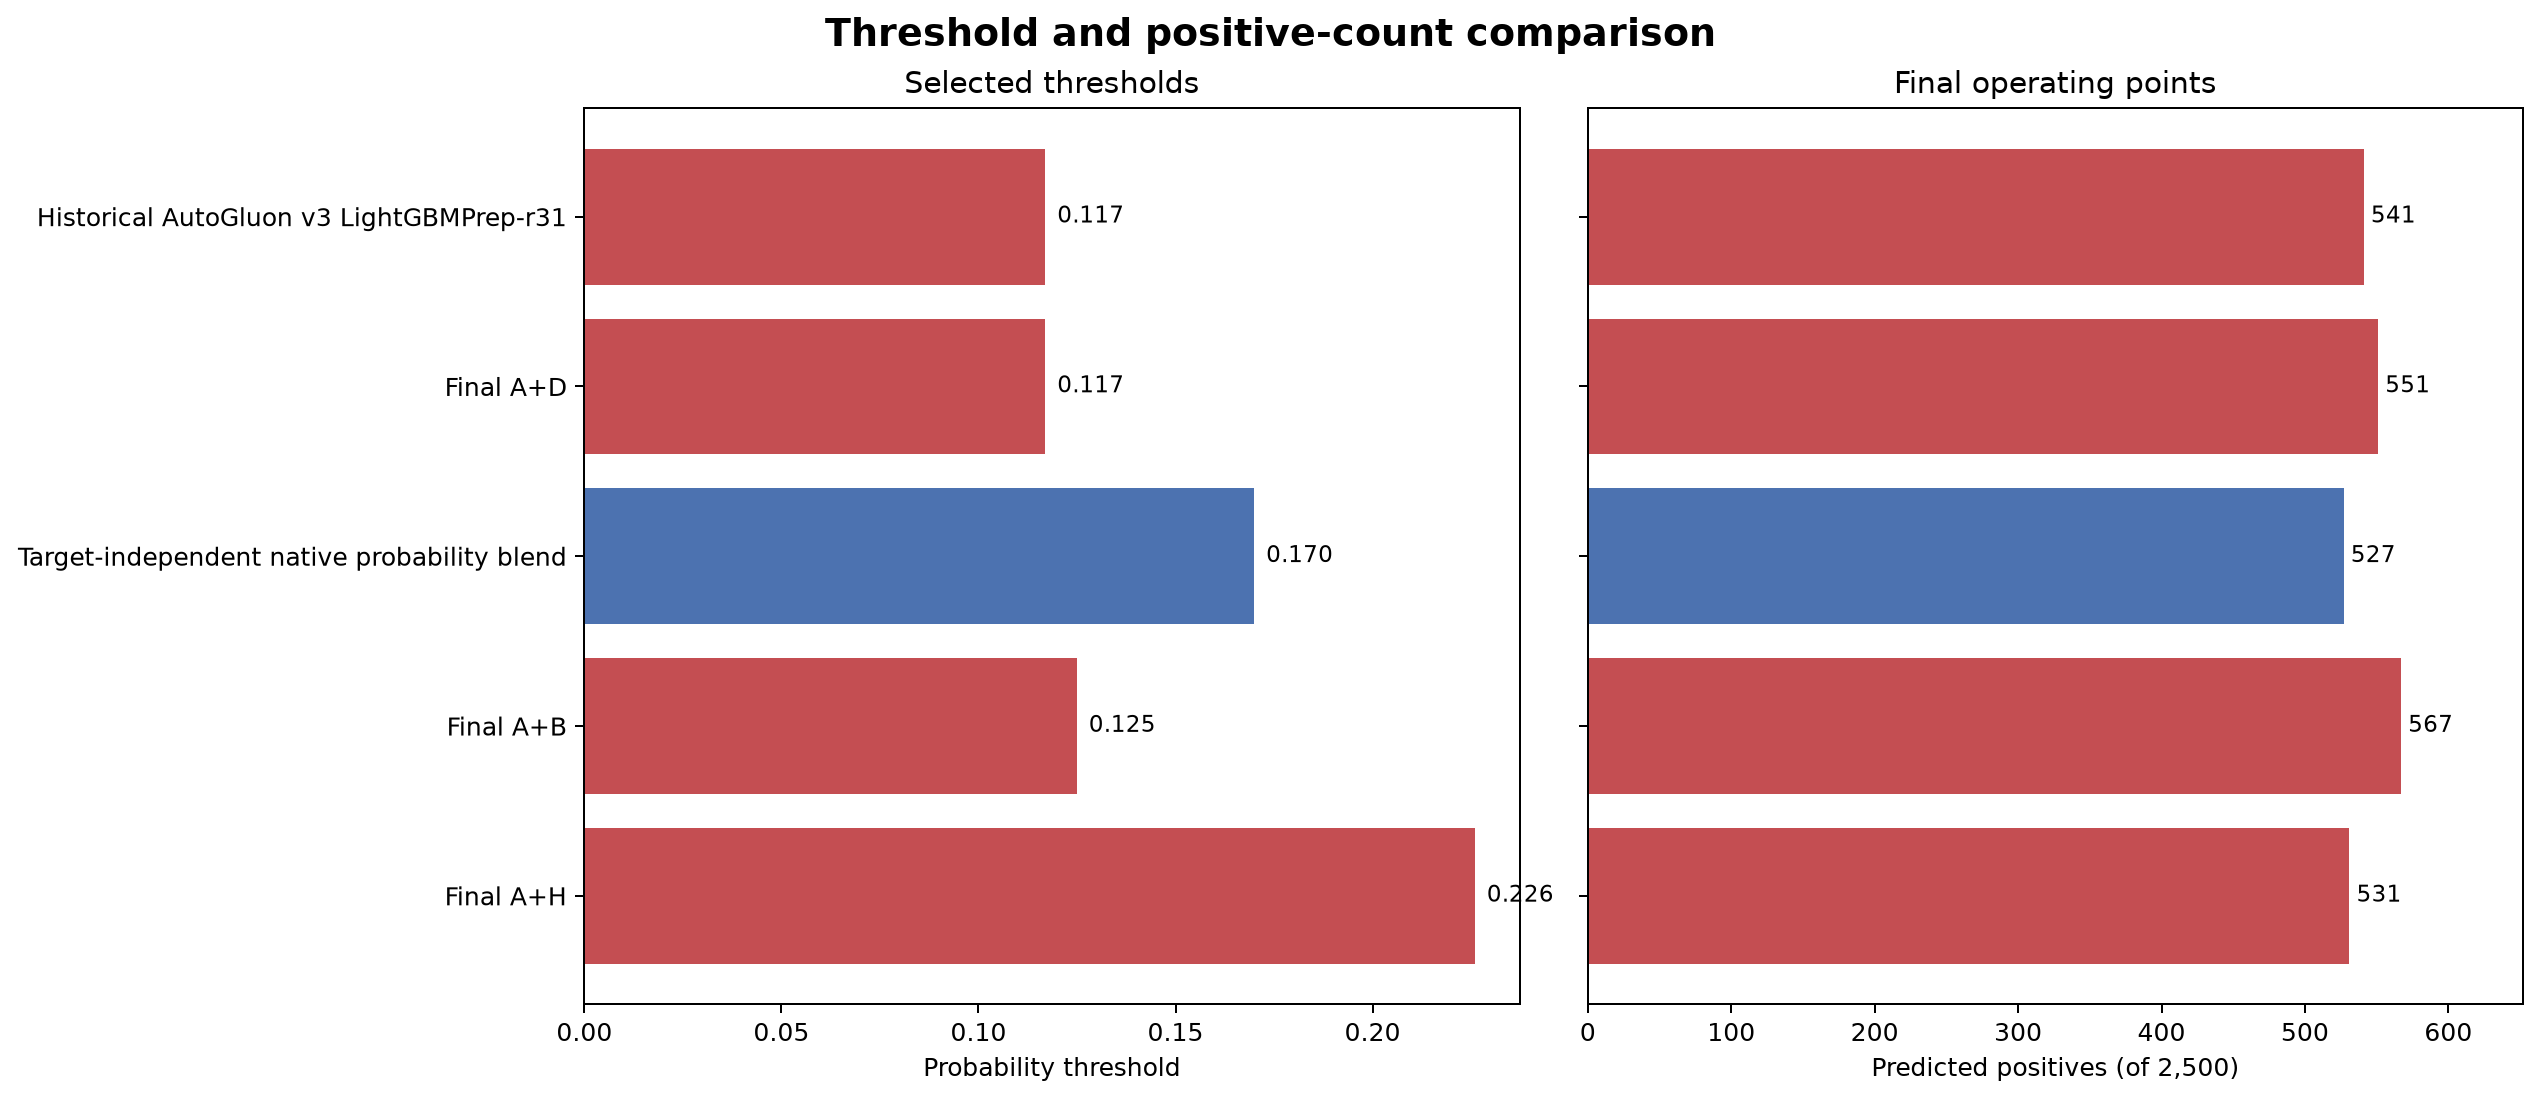

In [4]:
# Generate tracked publication assets from the compact evidence only.
sys.path.insert(0, str(ROOT / 'scripts'))
from generate_final_report_assets import generate_charts

chart_paths = generate_charts(evidence)
for chart_path in chart_paths:
    display(Image(filename=str(chart_path), width=1100))

## 6. Internal evidence та Kaggle Public Score

A+B був найстабільнішим internal candidate, але його Public Score — 0,9042. A+D став найкращим новим Public результатом — **0,9080**. Історичний AutoGluon-screened anchor зберіг найкращий Public Score — **0,9112**. Це не суперечність: Public leaderboard оцінює лише невідому підмножину test labels, тоді як модель обиралася за honest local protocol. Public Score є зовнішнім benchmark, а не project-owned optimization criterion. Private Score і фінальний rank ще невідомі.

In [5]:
portfolio = pd.DataFrame(evidence['selected_submissions'])
portfolio_view = portfolio[[
    'portfolio_rank', 'label', 'candidate_id', 'blend_id', 'threshold',
    'positive_count', 'internal_balanced_accuracy', 'internal_protocol',
    'public_score', 'exploratory'
]]
display(portfolio_view.style.format({
    'threshold': '{:.3f}',
    'internal_balanced_accuracy': '{:.6f}',
    'public_score': '{:.4f}',
}))

,portfolio_rank,label,candidate_id,blend_id,threshold,positive_count,internal_balanced_accuracy,internal_protocol,public_score,exploratory
0,1,Historical AutoGluon v3 LightGBMPrep-r31,pc1_d833780dcc6565cb,None,0.117,541,0.895158,"historical explicit OOF validation; descriptive, not final 5x5 meta-CV",0.9112,True
1,2,Final A+D,pc1_eef84ff4999c488a,pb1_1c6b3a8dbd482a6a,0.117,551,0.896129,exploratory_confirmation_v1 honest repeated 5x5 meta-CV mean,0.9080,True
2,3,Target-independent native probability blend,pc1_c54c97e9c32f33a2,pb1_d047ebe82811ef1a,0.170,527,0.898216,native blend honest 2-repeat 5-fold meta-CV mean; separate protocol,0.9048,False
3,4,Final A+B,pc1_671b589ae5111b0d,pb1_6ec07045204974b8,0.125,567,0.896420,exploratory_confirmation_v1 honest repeated 5x5 meta-CV mean,0.9042,True
4,5,Final A+H,pc1_9255274a6cbd3bab,pb1_1ca68e70755eea20,0.226,531,0.894780,exploratory_confirmation_v1 honest repeated 5x5 meta-CV mean,0.9039,True


## 7. Neural diversity screen

Кампанія `exploratory_neural_screen_v1` за plan hash `05bc790…` перевірила `NeuralNetTorch_r31` на `v3` як джерело diversity. Anchor мав honest mean BA 0,892843, а оптимізований A+Neural — 0,892420. Neural component не покращив anchor, тому його відхилено й не включено до подальшого blending.

## 8. Рівні відтворюваності та artifact policy

1. **Repository-only report reproduction:** main `.venv`, tracked evidence, виконання цього notebook; raw data і model artifacts не потрібні.
2. **Local submission verification:** потрібні canonical candidate/blend artifacts; навчання не потрібне, а готовність, row count, schema, positive count і SHA перевіряються локально.
3. **Full experimental reconstruction:** потрібні авторизовані Kaggle data, Dataset Packages, `.venv`, окрема `.venv-autogluon`, точні configs і значні обчислення та диск.

Raw data, processed Dataset Packages, predictors, model binaries, OOF/test probabilities, immutable campaign artifacts, MLflow state і submission CSV навмисно ігноруються Git. Локальний workspace може перевищувати 22 GB і 100 000 generated files. Репозиторій зберігає код, configs, contracts, tests, compact evidence і executed report. Exact final submission regeneration доступне, коли canonical local candidates присутні. Bitwise retraining reproducibility між різним hardware або версіями libraries не заявляється.

## 9. Команди відтворення

```powershell
# Main environment and report
uv sync --dev --extra ui
uv run jupyter nbconvert --to notebook --execute notebooks/09_final_project_report.ipynb --inplace

# Dataset Registry validation (requires local Dataset Packages)
uv run python scripts/run_dataset_registry.py scan --root data/processed
uv run python scripts/run_dataset_registry.py validate --root data/processed

# Control Panel
uv run --extra ui streamlit run apps/experiment_control_panel.py --server.headless true --server.port 8501

# Validate frozen campaigns; do not execute them for report reproduction
uv run python scripts/run_blend_campaign.py validate --config configs/blend_campaigns/exploratory_confirmation_v1.yaml

# Canonical local submission readiness (requires ignored local candidates)
uv run python scripts/generate_candidate_submission.py --help

# Optional isolated AutoGluon environment; not used by this notebook
.\.venv-autogluon\Scripts\python.exe scripts\run_autogluon.py --help
```

## 10. Обмеження та висновки

Основні обмеження: `v3` є target-informed exploratory dataset; internal protocols не всі ідентичні; Public leaderboard охоплює лише частину test labels; Private Score і rank невідомі; повне historical retraining є важким і не виконується цим звітом. Control Panel не претендує на завершеність усіх бажаних campaign-result views.

Фінальна чесна confirmation показала покращення A+B та A+D над anchor у спільному repeated 5×5 meta-CV. A+B був найстабільнішим internal candidate. A+D дав найкращий новий Public Score 0,9080. Водночас історичний exploratory AutoGluon-screened `LightGBMPrep_r31` зберіг найкращий перевірений Public Score 0,9112. Розбіжність local і Public ordering підкреслює правильну роль leaderboard: це зовнішня перевірка, а не інструмент налаштування. Фінальний portfolio з п'яти submissions заморожено; нове навчання, campaign rerun або Kaggle upload для цього звіту не потрібні.